# Tutorial: 3-Exact Steiner Algorithm for Bounded Edge Length

This notebook demonstrates the **3-Exact Steiner Algorithm** (Algorithm B) as proposed in the Paper:
> **"An efficient 3-approximation algorithm for the Steiner tree problem with the minimum number of Steiner points and bounded edge length"**  
> *Donghoon Shin & Sunghee Choi (2023)*

## Problem Definition
Given three terminal points $p_a, p_b, p_c$ and a maximum edge length $R$, find a Steiner junction point $p_J$ that minimizes the total number of Steiner points required to connect the three terminals, such that every edge in the resulting 3-star tree has length $\le R$.

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
import networkx as nx

# Import utilities from our standalone module
from steiner_3exact import *
from graph_tools import *
from two_cest_heu import *

## Step 1: Initialize Terminals
We define three points forming a triangle. If the triangle is non-obtuse ($< 120^\circ$), a 3-star junction is likely to provide a better solution than a simple Steinerized MST (Wedge).

Terminals: A(0.0, 5.0), B(-4.0, 0.0), C(4.0, 0.0)
R (Max edge length): 2.0


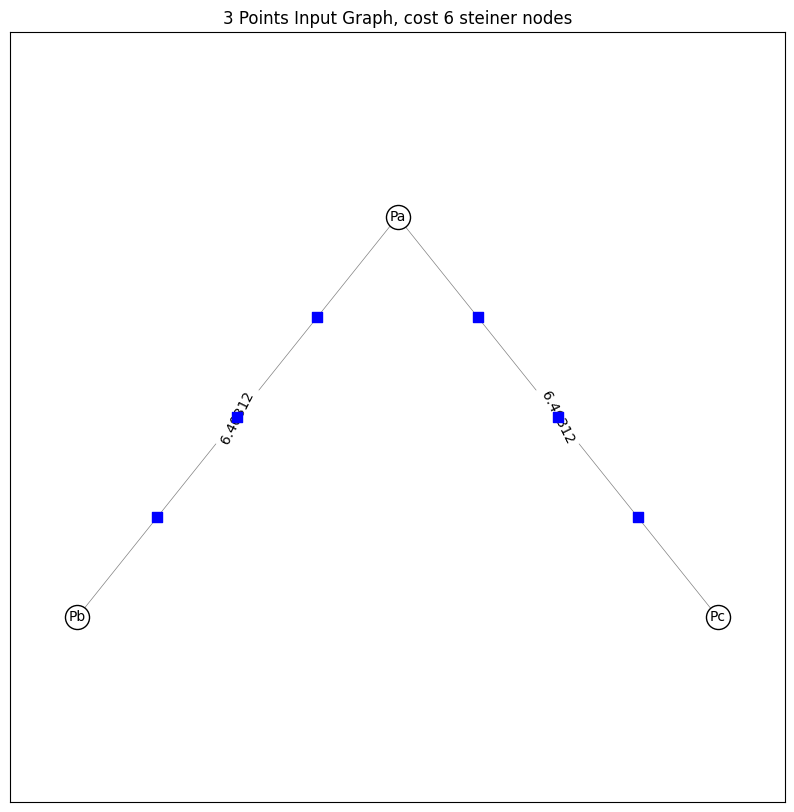

In [19]:
# Define terminals
Pa = Point(0.0, 5.0)
Pb = Point(-4.0, 0.0)
Pc = Point(4.0, 0.0)
# Maximum distance constraint
R = 2.0

print(f"Terminals: A{Pa.coords[0]}, B{Pb.coords[0]}, C{Pc.coords[0]}")
print(f"R (Max edge length): {R}")

three_point_graph = setup_three_point_graph(Pa, Pb, Pc)
st_nodes = calc_steinernize_MST(three_point_graph, R)

draw_graph(three_point_graph, f"3 Points Input Graph, cost {len(st_nodes)} steiner nodes", extra_points=st_nodes, show_nodes_labels=True, show_edges_label=True) 


## Step 2: Find the Fermat Point
The Fermat point ($p_F$) is the point that minimizes the sum of Euclidean distances to the three vertices. In the classical Steiner Tree problem (without length constraints), this is the optimal junction location.

Fermat Point: (0.0000, 2.3094)


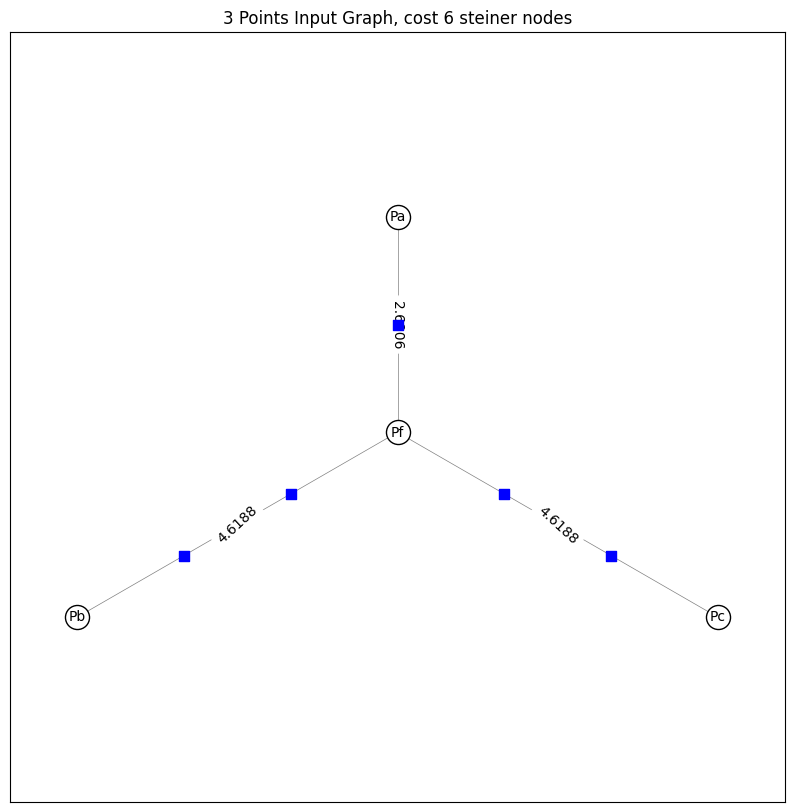

In [13]:
Pf = find_fermat_point(Pa, Pb, Pc)
Fermat_point_graph = setup_three_point_graph(Pa, Pb, Pc, Pf)
print(f"Fermat Point: ({Pf.x:.4f}, {Pf.y:.4f})")
st_nodes = calc_steinernize_MST(Fermat_point_graph, R)

draw_graph(Fermat_point_graph, f"3 Points Input Graph, cost {len(st_nodes)+1} steiner nodes", extra_points=st_nodes, show_nodes_labels=True, show_edges_label=True) 

## Step 3: Solve Equation (6) Optimization
The Paper introduces an exact algorithm that finds the optimal junction $p_J$ in constant time. 

### How it works:
1. **Normalization**: The triangle is rotated and scaled so $p_b = (0,0)$ and $p_c = (1,0)$.
2. **Steinerized Counts**: We calculate the "Steinerized count" (number of segments) from the junction to each terminal. Let these be $i, j, k$.
3. **Equation (6)**: A quartic polynomial is solved to determine the candidate values for the junction placement that satisfy the cost minimization objective.
4. **Discrete Search**: We check a small set of 8 Parameter configurations based on the Fermat point's hop counts to find the absolute minimum.

In [17]:
# Execute the 3-exact solver
opt_cost, Pj = solve_3exact_steiner(Pa, Pb, Pc, R)

print(f"Optimal Junction found: ({Pj.x:.4f}, {Pj.y:.4f}")
print(f"Minimum Steiner points required: {opt_cost}")

Optimal Junction found: (0.0000, 0.0000
Minimum Steiner points required: 5


## Step 4: Full 3-Star Tree Visualization
Finally, we visualize the complete 3-star tree, including the intermediate Steiner points added along the edges to satisfy the length constraint $R$.

Fermat Point: (0.0000, 0.0000)


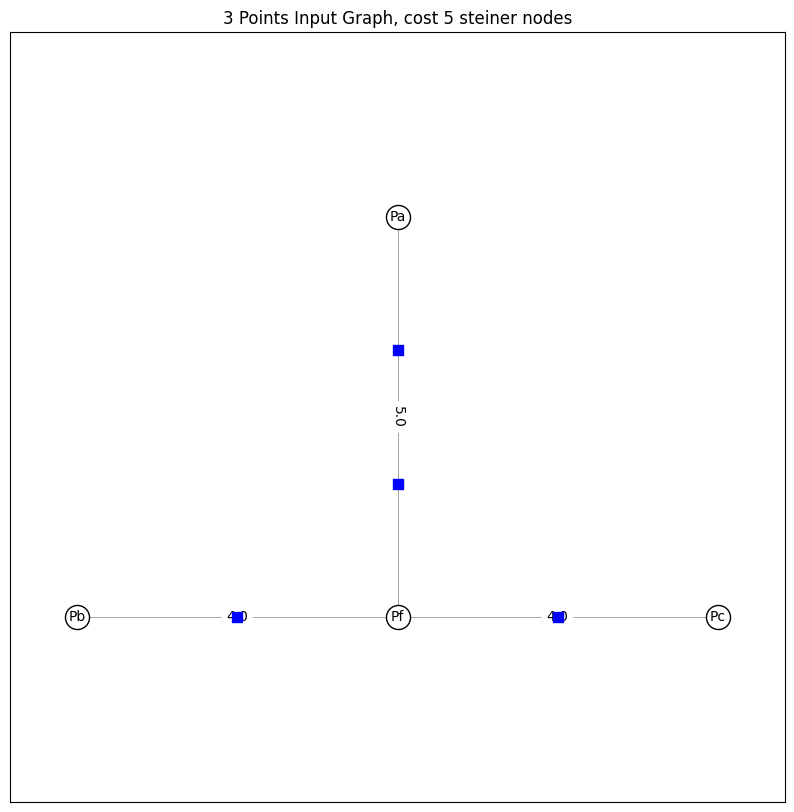

In [16]:
junction_point_graph = setup_three_point_graph(Pa, Pb, Pc, Pj)
print(f"Fermat Point: ({Pj.x:.4f}, {Pj.y:.4f})")
st_nodes = calc_steinernize_MST(junction_point_graph, R)

draw_graph(junction_point_graph, f"3 Points Input Graph, cost {len(st_nodes)+1} steiner nodes", extra_points=st_nodes, show_nodes_labels=True, show_edges_label=True) 